# Customer Segmentation using Unsupervised Machine Learning

## Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans

import warnings
warnings.filterwarnings('ignore')

## Load Dataset

In [2]:
df = pd.read_csv('new.csv')
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


## Dataset Information

In [3]:
df.shape

(2240, 29)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

## Checking Missing Values

In [5]:
df.isnull().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Z_CostContact           0
Z_Revenue               0
Response                0
dtype: int64

## Handling Missing Values

In [6]:
df = df.dropna()
print("Total values in the dataset after removing the null values:", len(df))

Total values in the dataset after removing the null values: 2216


## Checking Unique Values

In [7]:
df.nunique()

ID                     2216
Year_Birth               59
Education                 5
Marital_Status            8
Income                 1974
Kidhome                   3
Teenhome                  3
Dt_Customer             662
Recency                 100
MntWines                776
MntFruits               158
MntMeatProducts         554
MntFishProducts         182
MntSweetProducts        176
MntGoldProds            212
NumDealsPurchases        15
NumWebPurchases          15
NumCatalogPurchases      14
NumStorePurchases        14
NumWebVisitsMonth        16
AcceptedCmp3              2
AcceptedCmp4              2
AcceptedCmp5              2
AcceptedCmp1              2
AcceptedCmp2              2
Complain                  2
Z_CostContact             1
Z_Revenue                 1
Response                  2
dtype: int64

## Feature Engineering from Date Column

In [8]:
parts = df["Dt_Customer"].str.split("-", n=3, expand=True)

df["day"] = parts[0].astype('int')
df["month"] = parts[1].astype('int')
df["year"] = parts[2].astype('int')

## Removing Irrelevant Features

In [9]:
df.drop(['Z_CostContact', 'Z_Revenue', 'Dt_Customer'],
        axis=1,
        inplace=True)

## Identifying Categorical and Numerical Features

In [10]:
floats, objects = [], []
for col in df.columns:
    if df[col].dtype == object:
        objects.append(col)
    elif df[col].dtype == float:
        floats.append(col)

print(objects)
print(floats)

['Education', 'Marital_Status']
['Income']


## Count Plot of Categorical Features

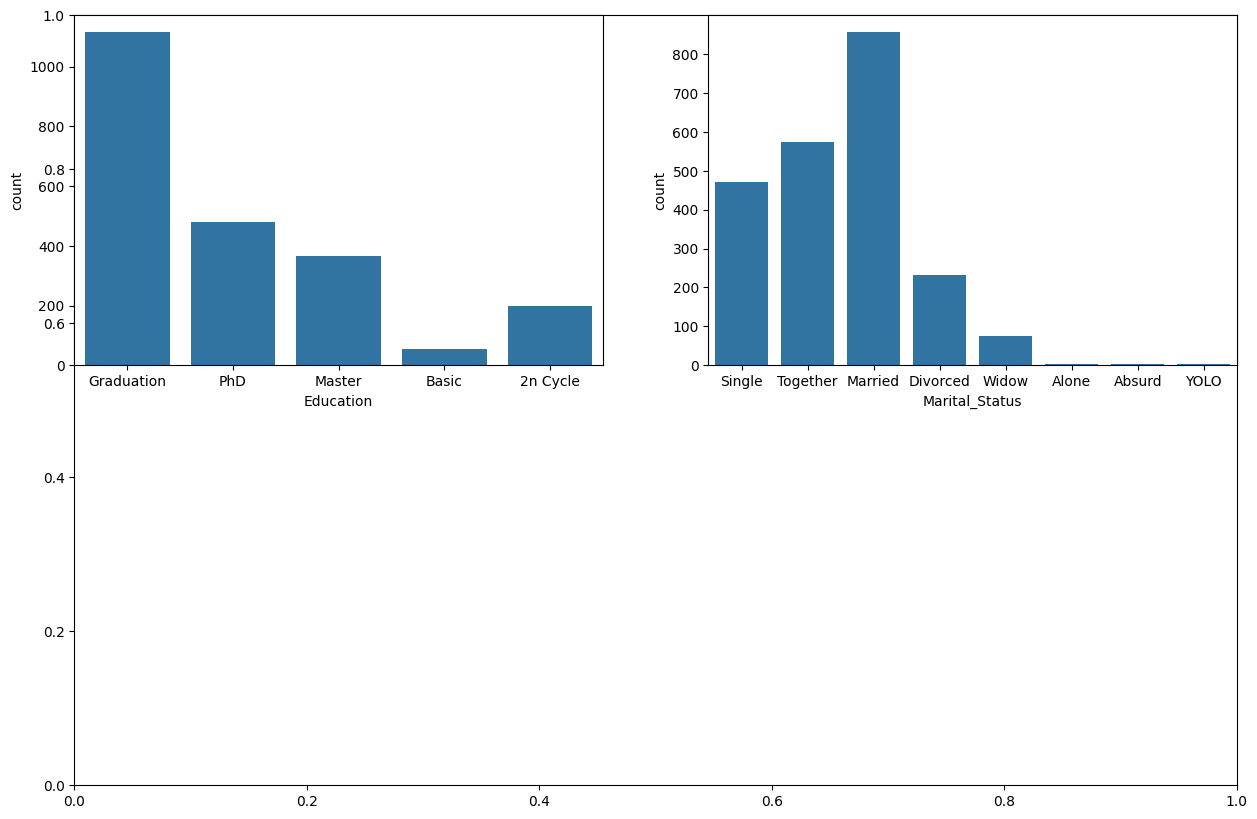

In [12]:
plt.subplots(figsize=(15, 10))

for i, col in enumerate(objects):
    plt.subplot(2, 2, i + 1)
    sb.countplot(x=df[col])

plt.show()

## Distribution of Marital Status

In [13]:
df['Marital_Status'].value_counts()

Marital_Status
Married     857
Together    573
Single      471
Divorced    232
Widow        76
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64

## Comparison of Categorical Features with Response

To understand the relationship between customer characteristics and campaign response, categorical features were compared against the response variable. This helps identify which customer groups are more likely to respond to marketing campaigns.

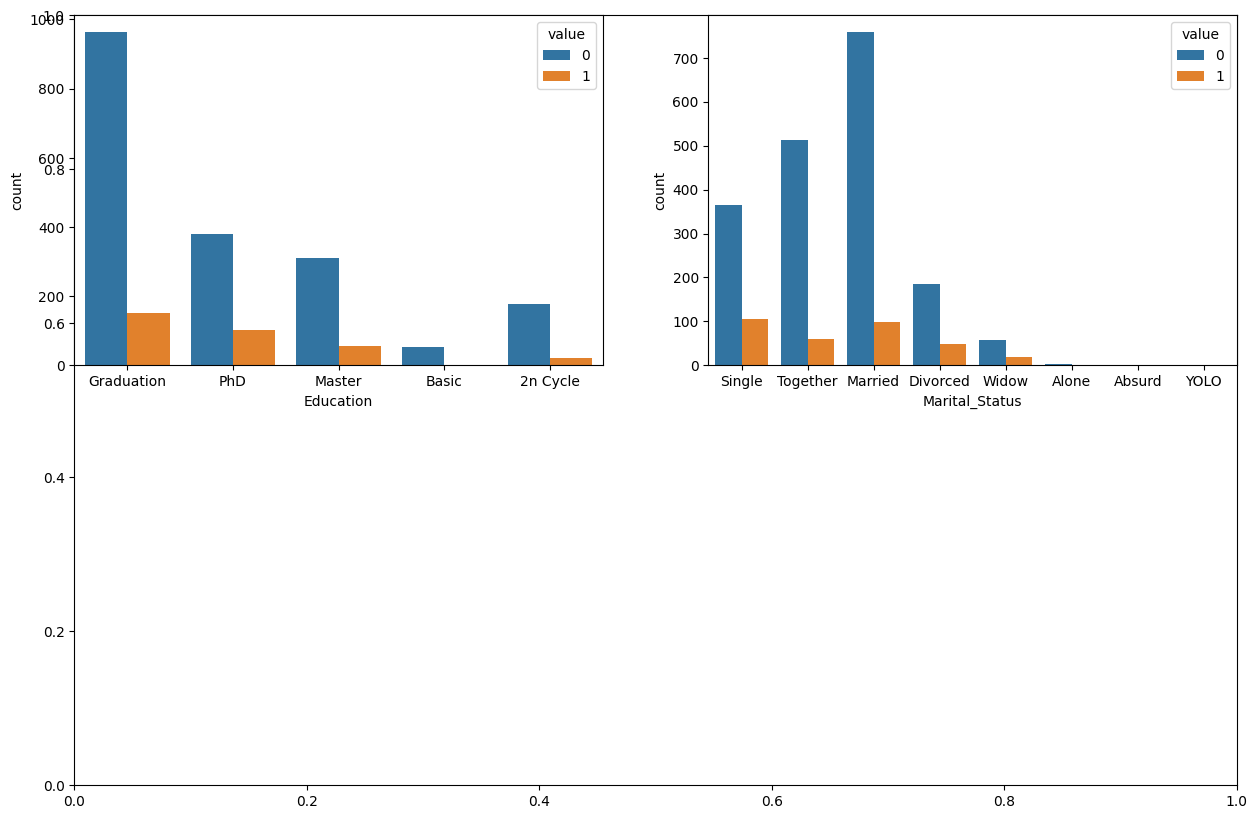

In [14]:
plt.subplots(figsize=(15, 10))
for i, col in enumerate(objects):
    plt.subplot(2, 2, i + 1)

    df_melted = df.melt(id_vars=[col], value_vars=['Response'], var_name='hue')
    sb.countplot(x=col, hue='value', data=df_melted)
plt.show()

## Label Encoding

Machine learning algorithms work with numerical data. Therefore, categorical features were converted into numerical values using Label Encoding. This transformation helps the clustering algorithm process categorical information effectively.

In [15]:
from sklearn.preprocessing import LabelEncoder

for col in df.columns:
    if df[col].dtype == object:
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col])

## Correlation Analysis using Heatmap

A heatmap was used to visualize the correlation among different features in the dataset. Highly correlated features may contain similar information and can influence the clustering process.

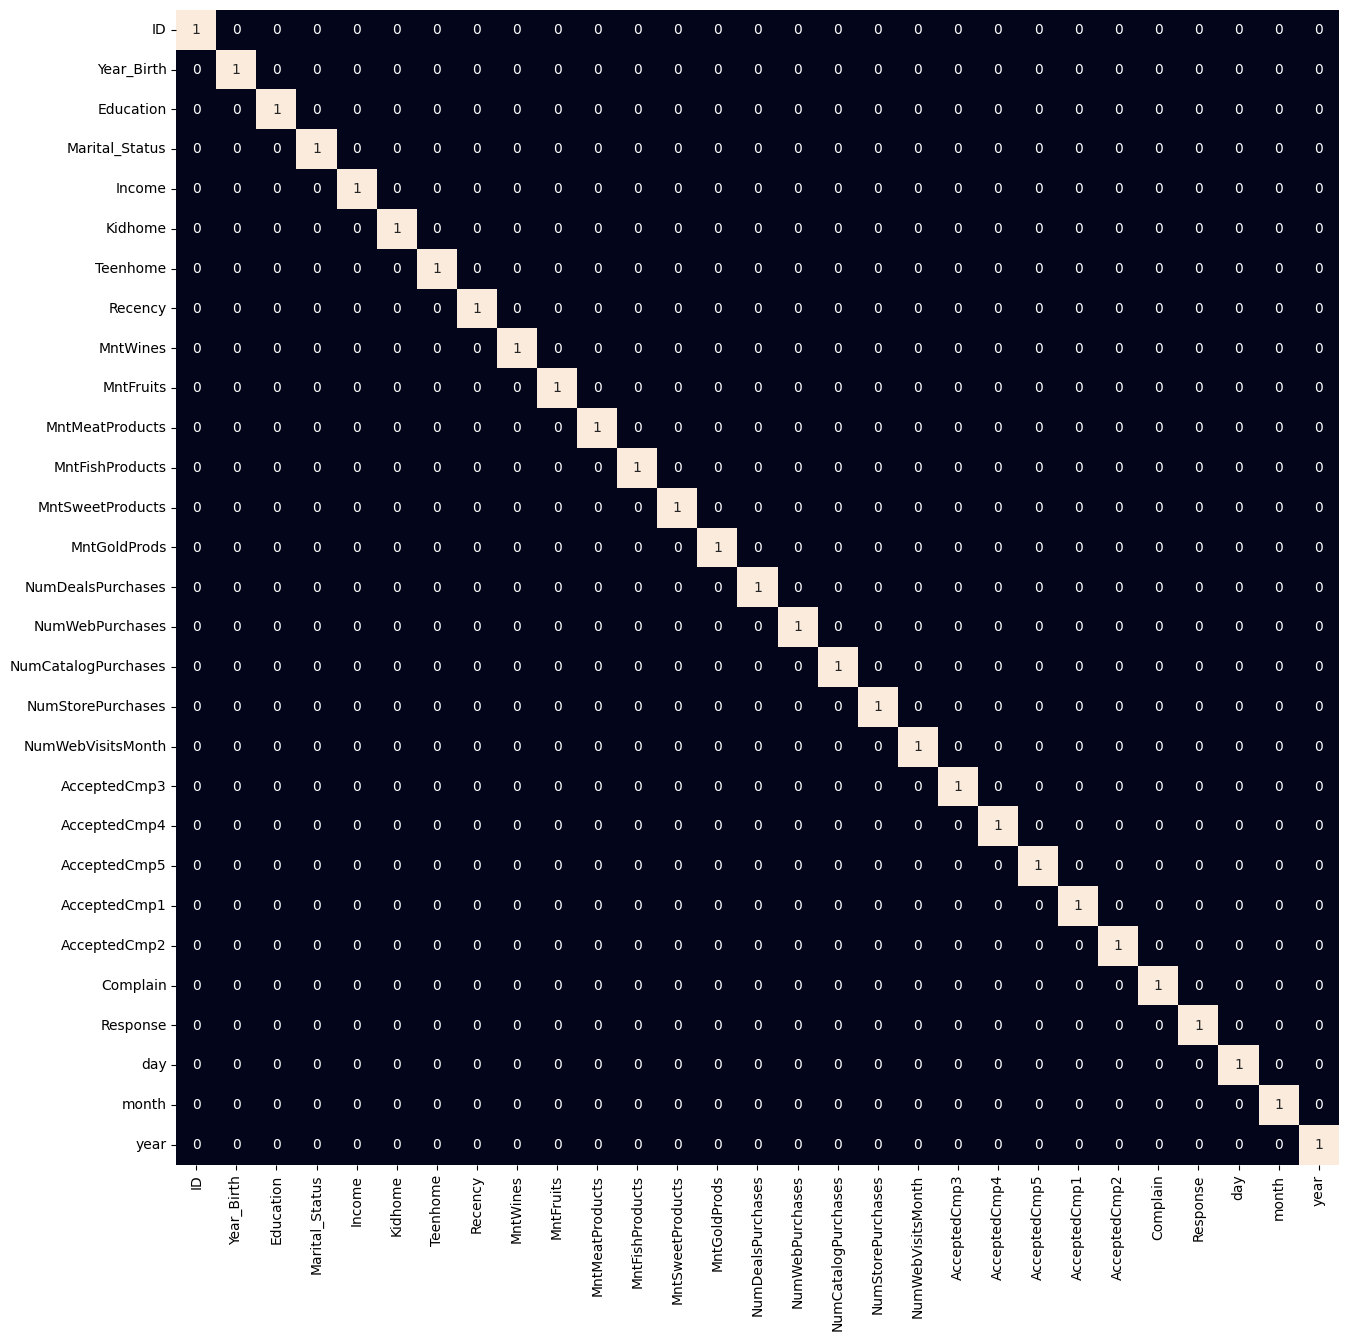

In [16]:
plt.figure(figsize=(15, 15))
sb.heatmap(df.corr() > 0.8, annot=True, cbar=False)
plt.show()

## Feature Scaling using Standardization

Feature scaling is an important preprocessing step in machine learning. Standardization transforms the data so that each feature has a mean of 0 and a standard deviation of 1. This ensures that all features contribute equally during clustering and dimensionality reduction.

In [17]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
data = scaler.fit_transform(df)

## Data Visualization using T-SNE

T-distributed Stochastic Neighbor Embedding (T-SNE) is a dimensionality reduction technique used to visualize high-dimensional data in two dimensions. It helps identify patterns and potential clusters in the dataset.

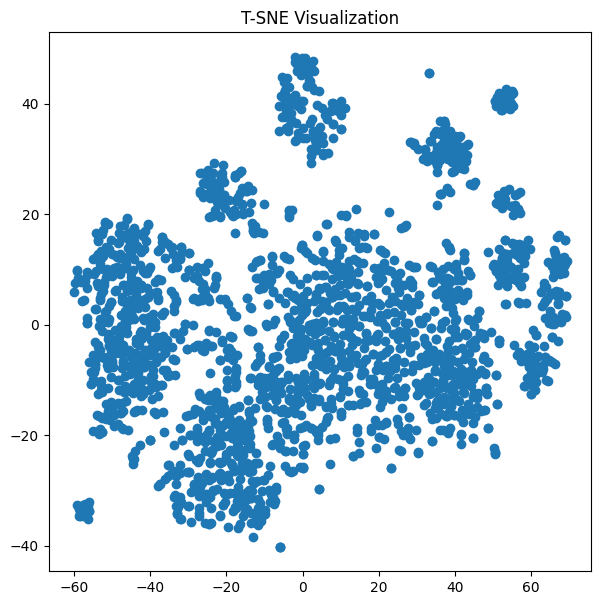

In [18]:
from sklearn.manifold import TSNE

model = TSNE(n_components=2, random_state=0)
tsne_data = model.fit_transform(data)

plt.figure(figsize=(7, 7))
plt.scatter(tsne_data[:, 0], tsne_data[:, 1])
plt.title("T-SNE Visualization")
plt.show()


## Finding the Optimal Number of Clusters

The Elbow Method is used to determine the optimal number of clusters for K-Means clustering. The inertia value represents the sum of squared distances of samples from their nearest cluster center. The point where the curve bends like an elbow is considered the optimal number of clusters.


In [19]:
from sklearn.cluster import KMeans

error = []

for n_clusters in range(1, 21):
    model = KMeans(
        init='k-means++',
        n_clusters=n_clusters,
        max_iter=500,
        random_state=22
    )

    model.fit(data)
    error.append(model.inertia_)

## Elbow Method Visualization

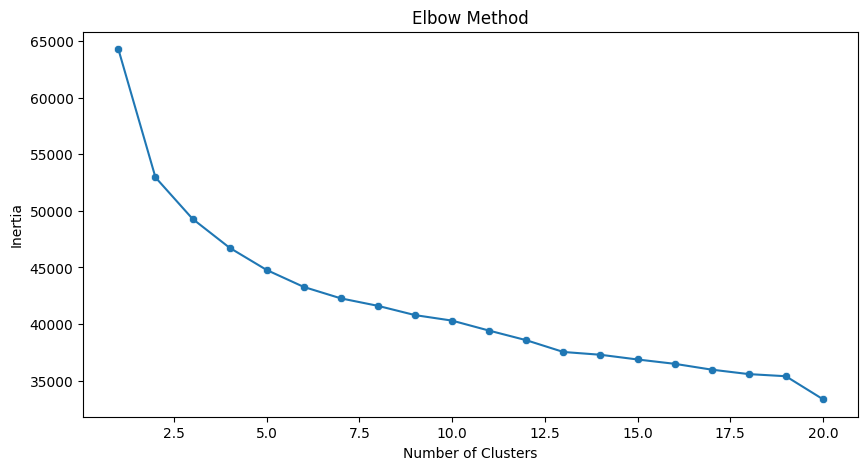

In [20]:
plt.figure(figsize=(10, 5))

sb.lineplot(x=range(1, 21), y=error)
sb.scatterplot(x=range(1, 21), y=error)

plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

### Observation

From the elbow curve, the rate of decrease in inertia slows after approximately 5–6 clusters. Therefore, K-Means clustering was performed using 5 clusters for customer segmentation.

## Applying K-Means Clustering

K-Means clustering was applied to divide customers into distinct groups based on their characteristics. Customers within the same cluster are more similar to each other than to customers in other clusters.

In [21]:
model = KMeans(
    init='k-means++',
    n_clusters=5,
    max_iter=500,
    random_state=22
)

segments = model.fit_predict(df)

## Visualization of Customer Segments

To better understand the clusters formed by K-Means clustering, T-SNE dimensionality reduction was used to project the high-dimensional dataset into a two-dimensional space. Each color in the scatter plot represents a different customer segment identified by the clustering algorithm.

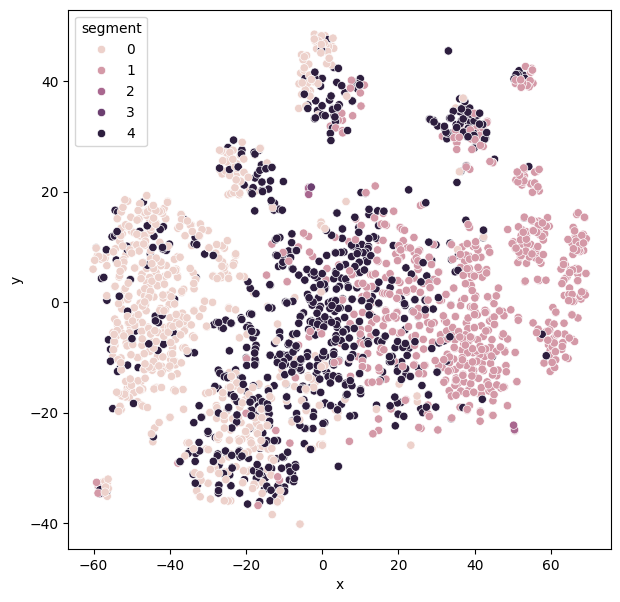

In [22]:
plt.figure(figsize=(7, 7))

df_tsne = pd.DataFrame({
    'x': tsne_data[:, 0],
    'y': tsne_data[:, 1],
    'segment': segments
})

sb.scatterplot(x='x', y='y', hue='segment', data=df_tsne)
plt.show()

# Conclusion

In this project, customer segmentation was performed using K-Means clustering. The dataset was preprocessed through data cleaning, feature engineering, label encoding, and standardization. T-SNE was used for visualization, while the Elbow Method helped determine the optimal number of clusters. The resulting customer segments can help businesses better understand customer behavior and develop targeted marketing strategies.